<a href="https://colab.research.google.com/github/RayhanPradana/PCVK_Rayhan-Pradana/blob/main/PCVK_Modul_5_Rayhan_Pradana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

Mengubah tingkat kecerahan citra dengan Gamma Correction
-------------------------------------------------------
Masukkan nilai gamma: 5


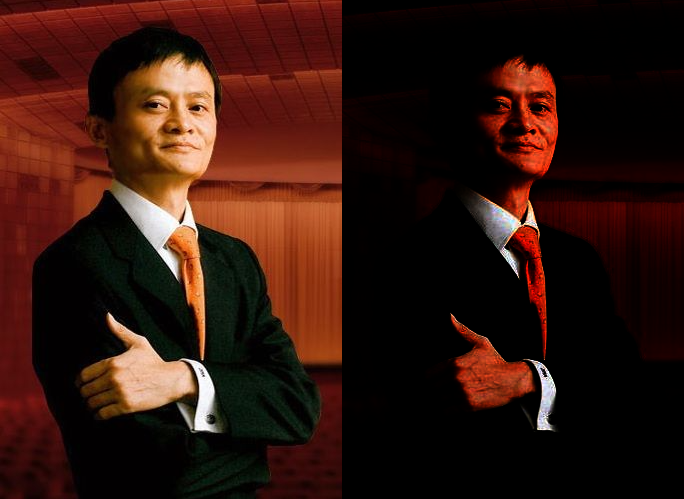

In [5]:
print('Mengubah tingkat kecerahan citra dengan Gamma Correction')
print('-------------------------------------------------------')

try:
    gamma = int(input('Masukkan nilai gamma: '))
except ValueError:
    print('Error, bukan angka')

original = cv.imread('/content/drive/MyDrive/Bahan PCVK/man.png')

normalized = original / 255.0
gamma_corrected = np.power(normalized, gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

final_frame = cv.hconcat((original, gamma_corrected))
cv2_imshow(final_frame)

Mengubah gambar berdasarkan bit depth
-------------------------------------


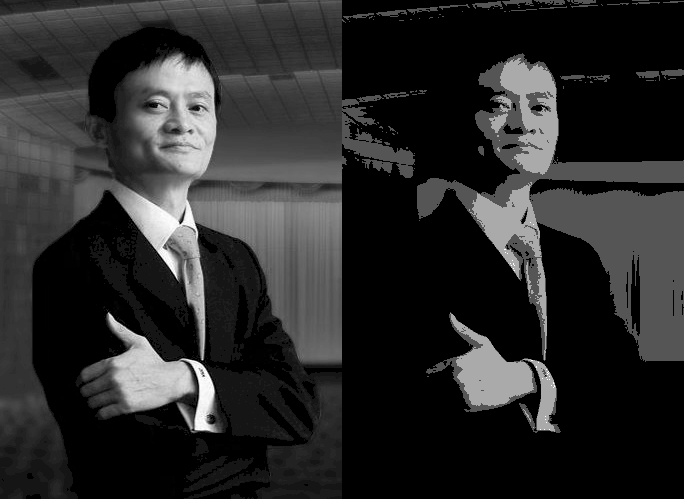

In [6]:
import cv2 as cv
import numpy as np

print('Mengubah gambar berdasarkan bit depth')
print('-------------------------------------')

bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/Bahan PCVK/man.png', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = np.clip((original[y, x] // level) * level, 0, 255)

final_frame = cv.hconcat((original, depth_image))
cv2_imshow(final_frame)

In [38]:
import cv2 as cv
import numpy as np
import glob
import math

def calculate_psnr(denoised1, denoised2):
    mse = np.mean((denoised1 - denoised2) ** 2)
    if mse == 0:  # Jika tidak ada kesalahan (MSE = 0), PSNR tak terhingga
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# Membuat list kosong untuk menyimpan semua citra dengan Gaussian Noise
cv_img = []

# Loop untuk membaca semua citra noise dari folder yang ditentukan
for img in glob.glob('/content/drive/MyDrive/Bahan PCVK/noises/galaxy.jpg'):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

# Cek apakah ada gambar yang berhasil dimuat
if len(cv_img) == 0:
    print("Tidak ada gambar yang berhasil dimuat dari folder.")
else:
    # Tentukan ukuran yang diinginkan (menggunakan ukuran citra pertama sebagai referensi)
    target_size = cv_img[0].shape[:2][::-1]  # (width, height)

    # Daftar jumlah gambar untuk diuji (5, 10, 20, 40, 80, 100)
    num_images_to_average = [5, 10, 20, 40, 80, 100]
    psnr_results = []

    # Melakukan average denoising dan menghitung PSNR untuk berbagai jumlah gambar
    for num_images in num_images_to_average:
        # Inisialisasi array float untuk menyimpan hasil penjumlahan
        average_image = np.zeros((target_size[1], target_size[0], 3), dtype=np.float32)  # (height, width, channels)

        # Menambahkan citra dari cv_img sebanyak num_images
        for i in range(num_images):
            if i < len(cv_img):  # Cek agar tidak mengakses index yang di luar range
                resized_image = cv.resize(cv_img[i], target_size)  # Mengubah ukuran citra agar sesuai
                average_image += resized_image

        # Menghitung rata-rata citra
        average_image /= num_images

        # Konversi kembali menjadi uint8 setelah perhitungan rata-rata
        denoised_image = np.uint8(average_image)

        # Menghitung PSNR antara dua gambar denoised (dari citra pertama dan hasil rata-rata)
        psnr_value = calculate_psnr(cv_img[0], denoised_image)
        psnr_results.append(psnr_value)

        # Menampilkan PSNR dan citra hasil
        print(f"Jumlah citra di average: {num_images}, PSNR: {psnr_value:.2f} dB")

        # Menambahkan keterangan pada gambar hasil
        keterangan = f'Jumlah citra: {num_images}, PSNR: {psnr_value:.2f} dB'
        cv.putText(denoised_image, keterangan, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # Simpan citra hasil untuk melihat output
        cv.imwrite(f'result_denoised_{num_images}.jpg', denoised_image)

    # Menampilkan hasil
    print("Hasil PSNR untuk setiap jumlah citra yang di-average:", psnr_results)


Jumlah citra di average: 5, PSNR: 28.14 dB
Jumlah citra di average: 10, PSNR: 27.59 dB
Jumlah citra di average: 20, PSNR: 27.56 dB
Jumlah citra di average: 40, PSNR: 27.54 dB
Jumlah citra di average: 80, PSNR: 27.60 dB
Jumlah citra di average: 100, PSNR: 27.61 dB
Hasil PSNR untuk setiap jumlah citra yang di-average: [28.14428614276236, 27.592873407618313, 27.560339534178205, 27.54290158704736, 27.60145829841015, 27.610026902375004]
